# OpenFoodFacts Global Nutrition Analysis

## Notebook 4: Data Visualization and Insights

### Objective

The objective of this notebook is to use focused visualizations to uncover meaningful nutritional patterns and relationships in the OpenFoodFacts dataset. Building on the exploratory analysis performed in the previous notebook, this stage focuses on comparing nutritional characteristics across product groups and identifying actionable insights from the data.

## Workflow

The following steps will be performed in this notebook:

1. Import the required libraries.
2. Configure notebook display settings.
3. Load the cleaned dataset.
4. Create a working copy of the dataset.
5. Compare nutritional quality across major countries.
6. Analyze nutritional characteristics across major food categories.
7. Compare nutritional profiles across PNNS food groups.
8. Examine relationships between key nutritional variables.
9. Identify important nutritional patterns and insights.
10. Summarize the major findings.

## Importing the Required Libraries

In this section, we import the Python libraries required for data visualization and analysis. These libraries provide tools for data manipulation, numerical operations, and visualization throughout the notebook.

In [1]:
# Import the required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Configuring Notebook Display Settings

To improve readability during data visualization and analysis, we configure display options that allow more rows, columns, and longer text values to be displayed without truncation.

In [2]:
# Configure notebook display settings

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", 100)
plt.style.use("default")

## Loading the Cleaned Dataset

The cleaned OpenFoodFacts dataset generated during the data preprocessing stage is loaded for visualization and further analysis.

In [3]:
# Load the cleaned dataset

food_df = pd.read_csv("../data/processed/openfoodfacts_cleaned.csv", low_memory = False)
food_df.shape

(356027, 64)

## Creating a Working Copy

A separate working copy of the dataset is created to perform visualization and analysis without modifying the original loaded dataset.

In [4]:
# Create a working copy for visualization

visual_df = food_df.copy()
visual_df.shape

(356027, 64)

In [5]:
# Calculate average nutrition score across major countries

country_nutrition = (visual_df.dropna(subset = ["countries_en", "nutrition-score-fr_100g"])
                    .groupby("countries_en")["nutrition-score-fr_100g"].agg(["mean", "count"])
                    .sort_values("count", ascending = False).head(10))
country_nutrition

,mean,count
countries_en,,
United States,9.449308,139076
France,8.799933,89045
Switzerland,9.084828,8865
Germany,9.402452,4813
Spain,5.507020,2564
United Kingdom,7.973753,1524
"France,Switzerland",10.089299,1299
"Belgium,France",10.521669,623
Belgium,9.346090,601


## Visualizing Nutritional Quality Across Major Countries

The average nutrition scores of the major country entries are visualized to make differences in nutritional quality easier to compare. The number of products represented by each country entry is also considered during the analysis to provide context for the comparison.

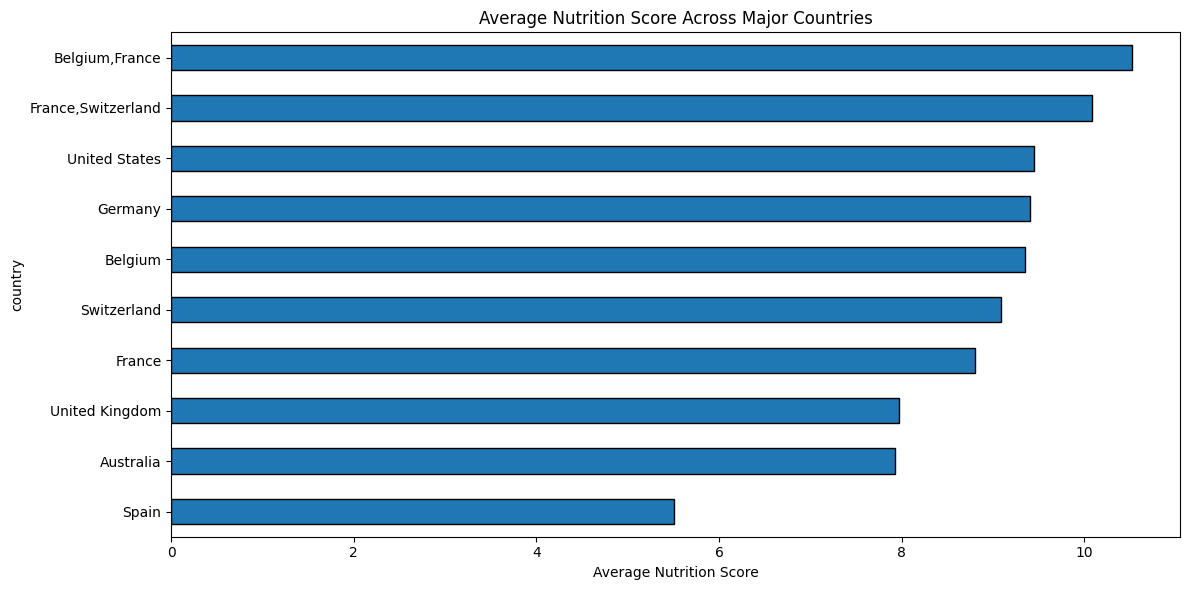

In [6]:
# Visualize average nutrition score across major countries

plt.figure(figsize = (12, 6))
country_nutrition["mean"].sort_values().plot(kind = "barh", edgecolor = "black")
plt.title("Average Nutrition Score Across Major Countries")
plt.xlabel("Average Nutrition Score")
plt.ylabel("country")
plt.tight_layout()
plt.savefig("../outputs/figures/average_nutrition_score_across_major_countries.png", dpi = 300, bbox_inches = "tight")
plt.show()

## Observation

The average nutrition scores vary across the major country entries represented in the dataset. Belgium,France and France,Switzerland have the highest average scores, while Spain has the lowest average score among the entries shown.

The United States and Germany also show relatively high average nutrition scores, whereas Australia and the United Kingdom have comparatively lower values.

These differences indicate variation in the nutritional profiles of products across country entries. However, the number of products represented by each country should also be considered when interpreting these differences, as country entries with smaller product counts may provide less representative estimates.

## Nutritional Characteristics Across Major Food Categories

This analysis examines the average nutritional characteristics of the major food categories represented in the dataset. The focus is on comparing nutritional profiles across categories rather than simply measuring the number of products in each category.

In [7]:
# Calculate average nutritional characteristics across major food categories

major_categories = (visual_df["categories_en"].dropna().value_counts().head(15).index)
category_nutrition = (visual_df[visual_df["categories_en"].isin(major_categories)]
                      .groupby("categories_en")[["energy_100g", "fat_100g",
                      "saturated-fat_100g", "sugars_100g", "proteins_100g",
                      "nutrition-score-fr_100g"]].mean())
category_nutrition

,energy_100g,fat_100g,saturated-fat_100g,sugars_100g,proteins_100g,nutrition-score-fr_100g
categories_en,,,,,,
"Beverages,Alcoholic beverages,Beers",221.738095,0.341034,0.070833,4.020000,1.778914,NaN
"Beverages,Non-sugared beverages",250.658123,0.715161,0.292242,10.708297,0.960124,10.780887
"Dairies,Milks",332.538797,3.234979,1.624550,6.758099,3.791778,1.491489
"Dairies,Yogurts",401.218085,3.427762,2.180771,10.720763,4.336237,2.020057
Fats,2908.741096,75.211671,23.531805,2.491812,3.724929,13.544582
"Groceries,Sauces",1007.587479,18.873582,2.914419,11.634820,1.880733,12.569659
"Groceries,Sauces,Tomato sauces,Ketchup",460.327652,0.321900,0.044429,21.036284,0.636129,13.446860
"Meats,Prepared meats,Hams,White hams",526.950685,4.315607,1.646343,0.710472,20.568767,6.022222
"Salty snacks,Appetizers,Crackers",1993.385891,21.808485,8.350229,5.362651,10.528735,16.111579


In [8]:
# Standardize nutritional characteristics for visual comparison

nutrition_features = ["energy_100g", "fat_100g", "saturated-fat_100g", "sugars_100g", "proteins_100g"]
category_nutrition_scaled = category_nutrition[nutrition_features].copy()
category_nutrition_scaled = (category_nutrition_scaled - category_nutrition_scaled.mean()) / category_nutrition_scaled.std()
category_nutrition_scaled

,energy_100g,fat_100g,saturated-fat_100g,sugars_100g,proteins_100g
categories_en,,,,,
"Beverages,Alcoholic beverages,Beers",-1.217683,-0.885345,-0.937832,-0.929978,-0.756104
"Beverages,Non-sugared beverages",-1.186903,-0.867216,-0.912787,-0.576885,-0.918561
"Dairies,Milks",-1.099757,-0.745113,-0.762078,-0.785426,-0.356731
"Dairies,Yogurts",-1.026661,-0.735772,-0.699160,-0.576227,-0.248705
Fats,1.642119,2.742657,1.716030,-1.010655,-0.369995
"Groceries,Sauces",-0.381296,0.012686,-0.616171,-0.527971,-0.735903
"Groceries,Sauces,Tomato sauces,Ketchup",-0.963750,-0.886272,-0.940819,-0.031643,-0.982845
"Meats,Prepared meats,Hams,White hams",-0.892842,-0.692749,-0.759613,-1.104697,2.971999
"Salty snacks,Appetizers,Crackers",0.667898,0.154902,-0.001282,-0.859096,0.979952


## Visualizing Nutritional Profiles Across Major Food Categories

A heatmap is used to compare the relative nutritional characteristics of the major food categories. Standardization allows variables with different measurement scales to be compared on the same visual scale. Higher positive values indicate above-average levels for the selected categories, while negative values indicate below-average levels.

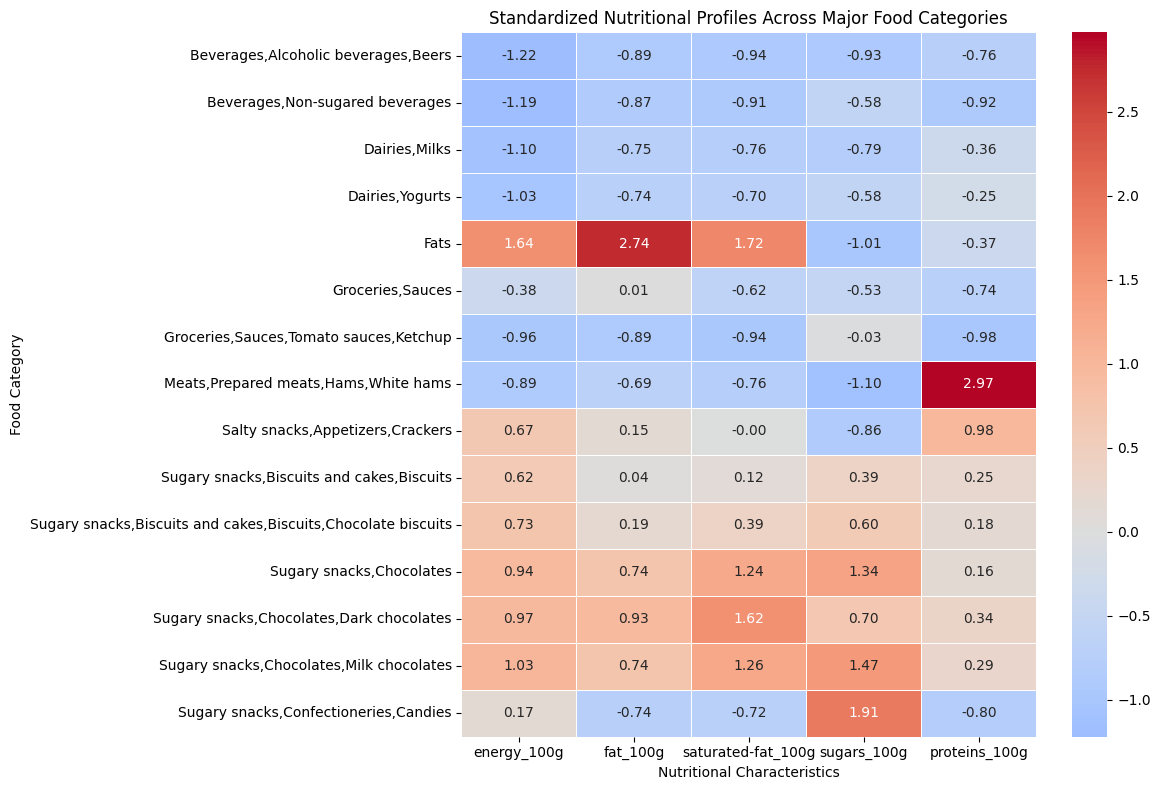

In [9]:
# Visualize standardized nutritional profiles across major food categories

plt.figure(figsize = (12, 8))
sns.heatmap(category_nutrition_scaled, annot = True, fmt = ".2f",
            center = 0, cmap = "coolwarm", linewidths = 0.5)
plt.title("Standardized Nutritional Profiles Across Major Food Categories")
plt.xlabel("Nutritional Characteristics")
plt.ylabel("Food Category")
plt.tight_layout()
plt.savefig("../outputs/figures/nutritional_profiles_across_major_food_categories.png", dpi = 300, bbox_inches = "tight")
plt.show()

## Observation

The heatmap shows clear differences in nutritional characteristics across the major food categories. Fats have particularly high relative levels of fat and saturated fat, while prepared meats and hams show a notably high relative protein level.

Sugary snack categories generally show higher relative energy and sugar levels. Chocolate and milk chocolate products also show relatively high saturated fat levels, while confectioneries and candies have the highest relative sugar levels among the categories shown.

In contrast, beverages, milks, and yogurts generally show below-average values across most of the selected nutritional characteristics. These differences highlight substantial variation in nutritional composition across food categories.

## Nutritional Profiles Across PNNS Food Groups

This analysis compares the nutritional characteristics of products across the major PNNS Level 1 food groups. The `unknown` category is excluded because it does not represent a specific PNNS food group. The comparison focuses on the nutritional composition of the identified food groups rather than their product counts.

In [10]:
# Calculate average nutritional characteristics across major PNNS Level 1 food groups

pnns_groups = (visual_df.loc[visual_df["pnns_groups_1"].notna() & (visual_df["pnns_groups_1"]
               != "unknown"), "pnns_groups_1"].value_counts().head(10).index)
pnns_nutrition = (visual_df[visual_df["pnns_groups_1"].isin(pnns_groups)].groupby("pnns_groups_1")
                 [["energy_100g", "fat_100g", "saturated-fat_100g", "sugars_100g", "proteins_100g",
                 "nutrition-score-fr_100g"]].mean())
pnns_nutrition

,energy_100g,fat_100g,saturated-fat_100g,sugars_100g,proteins_100g,nutrition-score-fr_100g
pnns_groups_1,,,,,,
Beverages,269.793403,0.778282,0.440460,12.058409,0.880155,8.840160
Cereals and potatoes,1354.168213,6.150873,1.698212,6.823449,10.255364,1.492990
Composite foods,699.313381,7.734249,2.614912,2.461107,7.620018,3.581416
Fat and sauces,1730.969053,42.198927,12.495959,6.255271,2.051847,12.349892
Fish Meat Eggs,875.794613,13.926112,4.554830,0.875526,18.712901,9.610290
Fruits and vegetables,445.075619,2.787437,0.976898,12.698681,2.205660,-2.240376
Milk and dairy products,798.588950,13.303975,8.753479,7.819328,9.293887,7.896970
Salty snacks,2126.603022,30.972723,5.575559,4.789284,10.580870,12.795812
Sugary snacks,1809.068157,19.496292,9.754913,41.336220,5.317468,17.609272


## Visualizing Nutritional Profiles Across PNNS Food Groups

A heatmap is used to compare the relative nutritional characteristics of the major PNNS Level 1 food groups. The nutritional variables are standardized so that differences in measurement scales do not distort the comparison. Positive values indicate above-average levels among the selected PNNS groups, while negative values indicate below-average levels.

In [11]:
# Standardize nutritional characteristics for PNNS comparison

pnns_nutrition_features = ["energy_100g", "fat_100g", "saturated-fat_100g", "sugars_100g", "proteins_100g"]
pnns_nutrition_scaled = pnns_nutrition[pnns_nutrition_features].copy()
pnns_nutrition_scaled = (pnns_nutrition_scaled - pnns_nutrition_scaled.mean()) / pnns_nutrition_scaled.std()
pnns_nutrition_scaled

,energy_100g,fat_100g,saturated-fat_100g,sugars_100g,proteins_100g
pnns_groups_1,,,,,
Beverages,-1.131085,-0.960828,-0.991440,0.196516,-1.122451
Cereals and potatoes,0.470489,-0.566779,-0.700169,-0.248076,0.593969
Composite foods,-0.496703,-0.450648,-0.487879,-0.618558,0.111488
Fat and sauces,1.027008,2.077140,1.800380,-0.296330,-0.907936
Fish Meat Eggs,-0.236048,0.003490,-0.038632,-0.753218,2.142381
Fruits and vegetables,-0.872201,-0.813468,-0.867211,0.250893,-0.879776
Milk and dairy products,-0.350077,-0.042140,0.933694,-0.163498,0.417941
Salty snacks,1.611342,1.253762,0.197749,-0.420832,0.653563
Sugary snacks,1.142357,0.412031,1.165606,2.683006,-0.310064


## Visualizing PNNS Nutritional Profiles

The standardized nutritional profiles are visualized using a heatmap to highlight differences in energy, fat, saturated fat, sugars, and protein across the major PNNS Level 1 food groups.

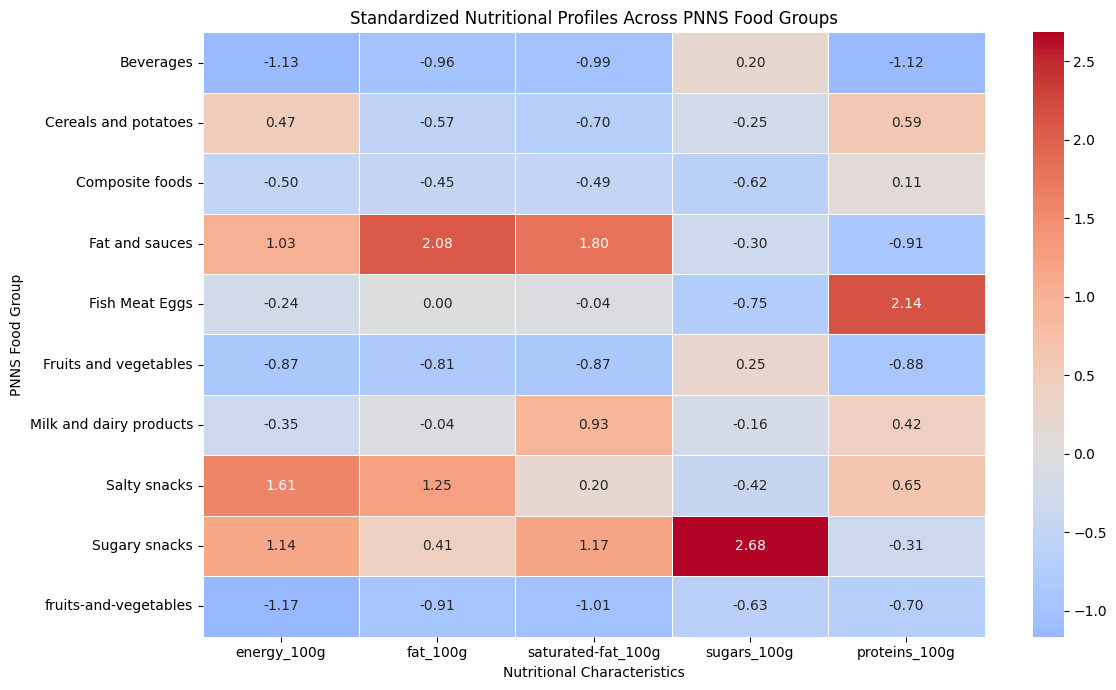

In [12]:
# Visualize standardized nutritional profiles across PNNS food groups

plt.figure(figsize = (12, 7))
sns.heatmap(pnns_nutrition_scaled, annot = True, fmt = ".2f",
            center = 0, cmap = "coolwarm", linewidths = 0.5)
plt.title("Standardized Nutritional Profiles Across PNNS Food Groups")
plt.xlabel("Nutritional Characteristics")
plt.ylabel("PNNS Food Group")
plt.tight_layout()
plt.savefig("../outputs/figures/nutritional_profiles_across_pnns_food_groups.png", dpi = 300, bbox_inches = "tight")
plt.show()

## Observation

The PNNS food groups show distinct nutritional profiles across the selected characteristics. Fat and sauces have particularly high relative levels of fat and saturated fat, while salty snacks show relatively high energy and fat levels.

Sugary snacks stand out for their substantially higher relative sugar content and also show above-average energy and saturated fat levels. Fish Meat Eggs have the highest relative protein level among the groups shown.

In contrast, beverages and fruits and vegetables generally show below-average levels across most nutritional characteristics. These differences demonstrate that nutritional composition varies considerably across broad PNNS food groups.

## Relationships Between Key Nutritional Variables

This section examines relationships between selected nutritional variables using scatter plots. The analysis focuses on meaningful nutritional relationships identified during the exploratory analysis while avoiding repetition of the correlation matrix presented in Notebook 3.

In [13]:
# Prepare a sample for visualizing nutritional relationships

relationship_df = visual_df[["energy_100g", "fat_100g", "saturated-fat_100g", "carbohydrates_100g",
                             "sugars_100g"]].dropna().sample(n = 5000, random_state = 42)
relationship_df.shape

(5000, 5)

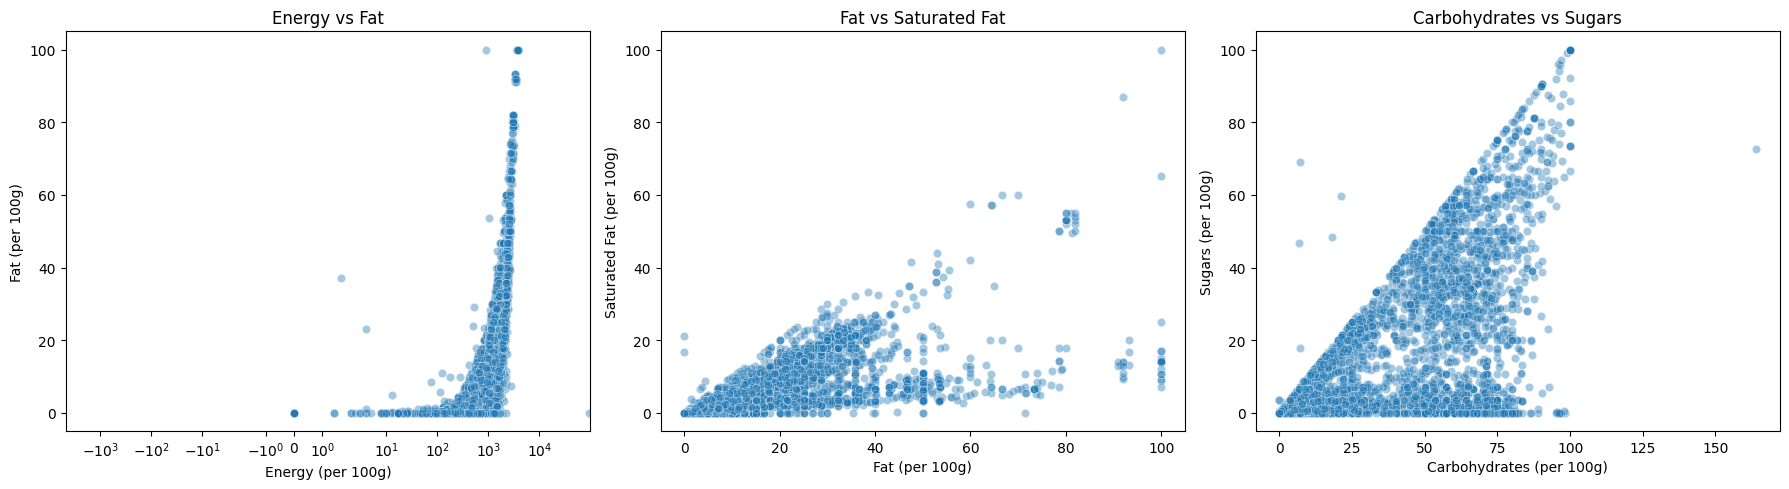

In [14]:
# Visualize key relationships between nutritional variables

fig, axes = plt.subplots(1, 3, figsize = (18, 5))
sns.scatterplot(data = relationship_df, x = "energy_100g", y = "fat_100g", alpha = 0.4, ax = axes[0])
axes[0].set_xscale("symlog")
axes[0].set_title("Energy vs Fat")
axes[0].set_xlabel("Energy (per 100g)")
axes[0].set_ylabel("Fat (per 100g)")

sns.scatterplot(data = relationship_df, x = "fat_100g", y = "saturated-fat_100g", alpha = 0.4, ax = axes[1])
axes[1].set_title("Fat vs Saturated Fat")
axes[1].set_xlabel("Fat (per 100g)")
axes[1].set_ylabel("Saturated Fat (per 100g)")

sns.scatterplot(data = relationship_df, x = "carbohydrates_100g", y = "sugars_100g", alpha = 0.4, ax = axes[2])
axes[2].set_title("Carbohydrates vs Sugars")
axes[2].set_xlabel("Carbohydrates (per 100g)")
axes[2].set_ylabel("Sugars (per 100g)")

plt.savefig("../outputs/figures/key_nutritional_relationships.png", dpi = 300, bbox_inches = "tight")
plt.tight_layout()
plt.show()              

## Observation

The scatter plots reveal clear positive relationships between several nutritional variables. Energy generally increases as fat content increases, although the relationship shows substantial variation and several extreme observations.

Fat and saturated fat also show a positive relationship, indicating that products with higher fat content tend to have higher saturated-fat levels. The relationship between carbohydrates and sugars is particularly clear, with sugar content generally increasing as carbohydrate content increases.

Overall, the visualizations demonstrate meaningful relationships among key nutritional characteristics while also showing variation and potential extreme values within the dataset.

## Key Nutritional Patterns and Insights

The visual analysis reveals several important patterns in the nutritional characteristics of products in the dataset.

- Nutritional scores vary across major countries, indicating differences in the nutritional profiles of products represented from different markets.
- Major food categories show substantial differences in nutritional composition. Fats have particularly high fat and saturated-fat levels, while sugary snack categories generally show higher energy and sugar levels.
- PNNS food groups also display distinct nutritional profiles. Fat and sauces have high relative fat and saturated-fat levels, sugary snacks have notably high sugar levels, and the Fish Meat Eggs group has a relatively high protein level.
- Fruits and vegetables generally show lower relative levels of energy, fat, saturated fat, and protein compared with several other PNNS groups.
- Strong positive relationships are visible between energy and fat, fat and saturated fat, and carbohydrates and sugars.
- The scatter plots also reveal considerable variation and some extreme observations, highlighting the diversity of nutritional composition within the dataset.

Overall, the visualizations demonstrate that nutritional characteristics differ substantially across countries, food classifications, and product types, while several nutritional variables exhibit clear relationships with one another.

## Summary of Major Findings

The visual analysis helped us understand how nutritional characteristics vary across different parts of the dataset. The comparison across countries showed noticeable differences in average nutrition scores, while the analysis of food categories revealed clear differences in their nutritional composition.

Sugary snack categories generally showed higher energy and sugar levels, with chocolate-based products also showing relatively high fat and saturated-fat levels. Fats and sauces had particularly high fat and saturated-fat content, while prepared meats and the Fish Meat Eggs PNNS group stood out for their relatively high protein levels.

The PNNS analysis also showed that different food groups have distinct nutritional profiles. Fruits and vegetables generally had lower relative levels of several nutritional characteristics, while sugary snacks and salty snacks showed higher energy and fat-related values.

The relationship analysis showed clear positive relationships between energy and fat, fat and saturated fat, and carbohydrates and sugars. At the same time, the scatter plots showed considerable variation and some extreme observations within the products.

Overall, the visualizations provided a clearer picture of the nutritional patterns in the dataset and helped identify meaningful differences across countries, food categories, and PNNS food groups. These findings provide a useful basis for the next stage of the project, where the identified patterns can be explored further and translated into more specific insights.